In [ ]:
#!unzip /content/sample_data/archive.zip -d /content/sample_data/

# Fase 1 — Reconocimiento de Patrones: Firmas en Cheques Off-Line

**Descripción general**

La verificación de firmas *off-line* trabaja sobre imágenes de cheques en papel. A diferencia de la verificación *on-line*, la información dinámica del trazo se pierde, por lo que el sistema debe apoyarse en características morfológicas extraídas de la imagen.

El flujo de trabajo completo es:

```
Cheque real (imagen completa)
        │
        ▼
  ┌─────────────┐
  │  U-Net      │  ← entrenada con pares (X_cheque, y_firma)
  │  Segmentación│
  └──────┬──────┘
         │  Máscara de firma
         ▼
  Post-procesamiento (binarización, limpieza, recorte)
         │
         ▼
  Extracción de características (54 EE morfológicos)
         │
         ▼
  Clasificadores (BPNN · SVM · KNN · Naive Bayes)
         │
         ▼
  Auténtica / Falsificación
```

---

## 0 · Dependencias

In [ ]:
# ── Instalación (ejecutar sólo la primera vez) ────────────────────────────────
# !pip install torch torchvision opencv-python-headless numpy matplotlib scikit-image scikit-learn tqdm

import os, re, random, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from skimage import filters, morphology
from skimage.morphology import binary_erosion
from scipy.ndimage import rotate as ndrotate

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
np.random.seed(42); random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✔  Dependencias cargadas.  Dispositivo: {DEVICE}')


✔  Dependencias cargadas.  Dispositivo: cuda


---
## Etapa 1 · Selección de Datos
### Adquisición y carga de imágenes de cheques con firmas off-line

El conjunto de datos tiene la siguiente estructura:
```
dataset/
├── TrainSet/
│   ├── X/   ← cheque completo         (X_<n>.png)
│   └── y/   ← firma aislada, negativo (y_<n>.png)
└── TestSet/
    ├── X/
    └── y/
```
Los pares `(X_n, y_n)` se usan para entrenar la U-Net. Las imágenes en `y` son el **ground truth de segmentación**: la firma aislada en negativo (trazo oscuro sobre fondo claro, o viceversa según el dataset). La red aprende a localizar y extraer la firma desde el cheque completo.

In [ ]:
# ── Configuración de rutas ────────────────────────────────────────────────────
DATASET_ROOT = '/content/sample_data/'

PATHS = {
    'train_X': os.path.join(DATASET_ROOT, 'TrainSet', 'X'),
    'train_y': os.path.join(DATASET_ROOT, 'TrainSet', 'y'),
    'test_X' : os.path.join(DATASET_ROOT, 'TestSet',  'X'),
    'test_y' : os.path.join(DATASET_ROOT, 'TestSet',  'y'),
}

IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def sorted_images(folder):
    files = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    files.sort(key=lambda f: int(re.search(r'(\d+)', f).group()))
    return [os.path.join(folder, f) for f in files]

train_X_paths = sorted_images(PATHS['train_X'])
train_y_paths = sorted_images(PATHS['train_y'])
test_X_paths  = sorted_images(PATHS['test_X'])
test_y_paths  = sorted_images(PATHS['test_y'])

assert len(train_X_paths) == len(train_y_paths), 'Pares train no coinciden'
assert len(test_X_paths)  == len(test_y_paths),  'Pares test no coinciden'

print(f'Pares de entrenamiento : {len(train_X_paths)}')
print(f'Pares de prueba        : {len(test_X_paths)}')

Pares de entrenamiento : 129
Pares de prueba        : 29


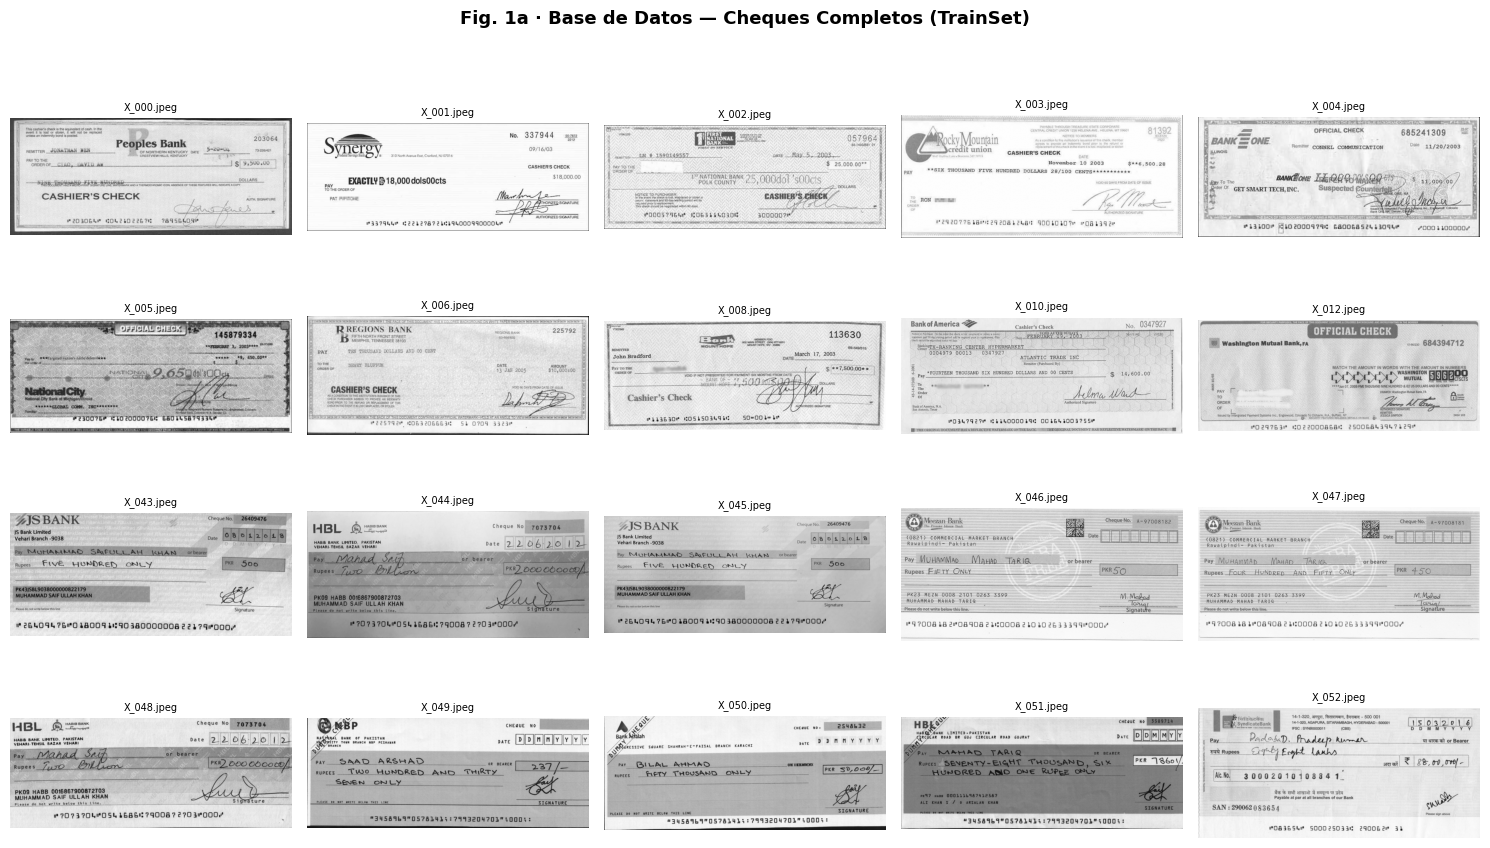

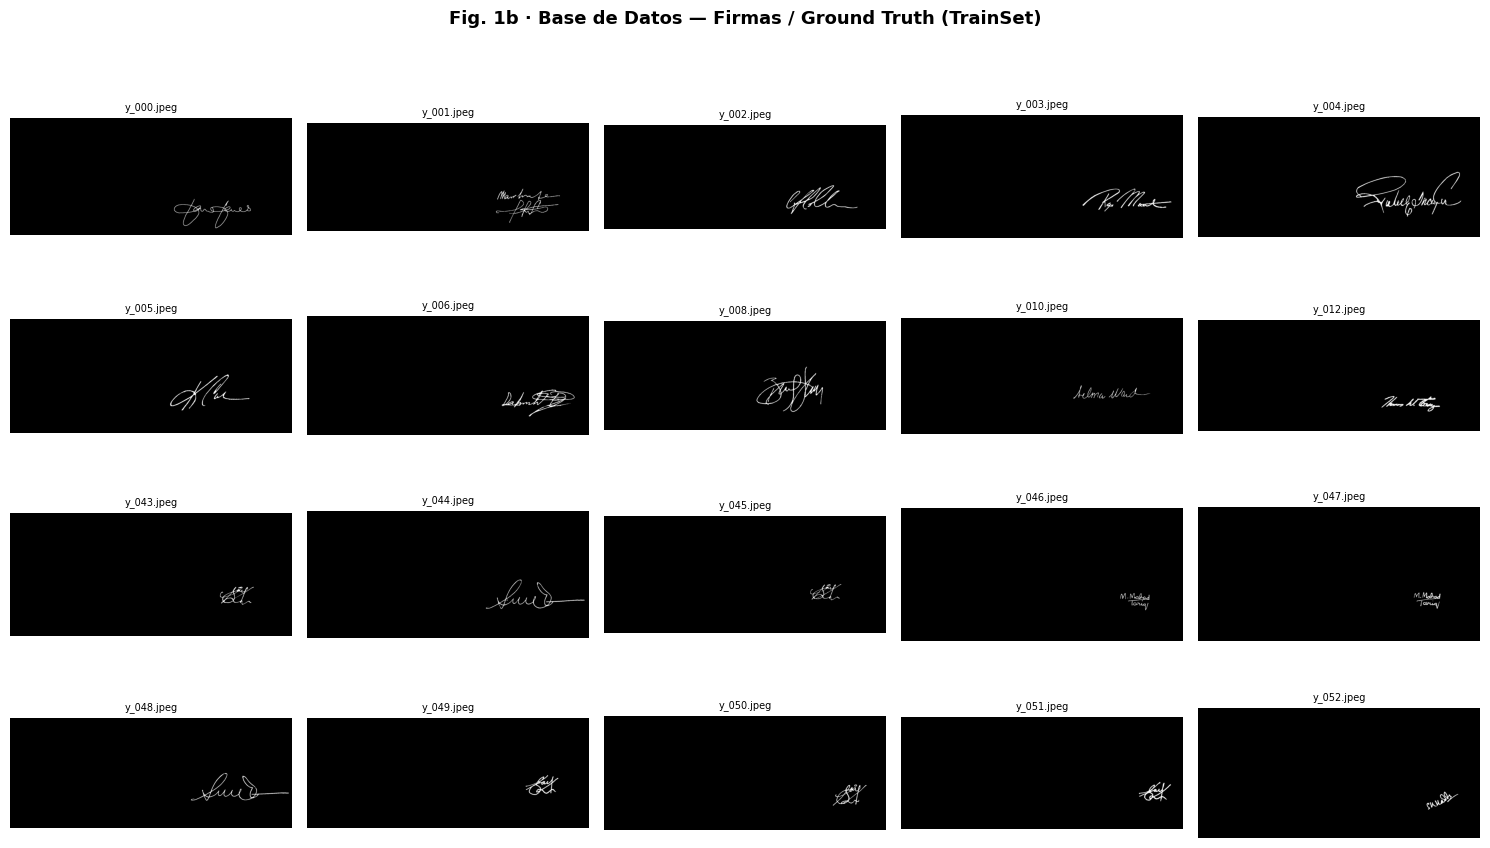

In [ ]:
# ── Fig. 1 · Mosaico de la base de datos ─────────────────────────────────────
def plot_mosaic(paths, title, cols=5, max_imgs=20):
    paths = paths[:max_imgs]
    rows  = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.2))
    axes = np.array(axes).flatten()
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p).convert('L')), cmap='gray')
        ax.set_title(os.path.basename(p), fontsize=7)
        ax.axis('off')
    for ax in axes[len(paths):]: ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

plot_mosaic(train_X_paths, 'Fig. 1a · Base de Datos — Cheques Completos (TrainSet)')
plot_mosaic(train_y_paths, 'Fig. 1b · Base de Datos — Firmas / Ground Truth (TrainSet)')

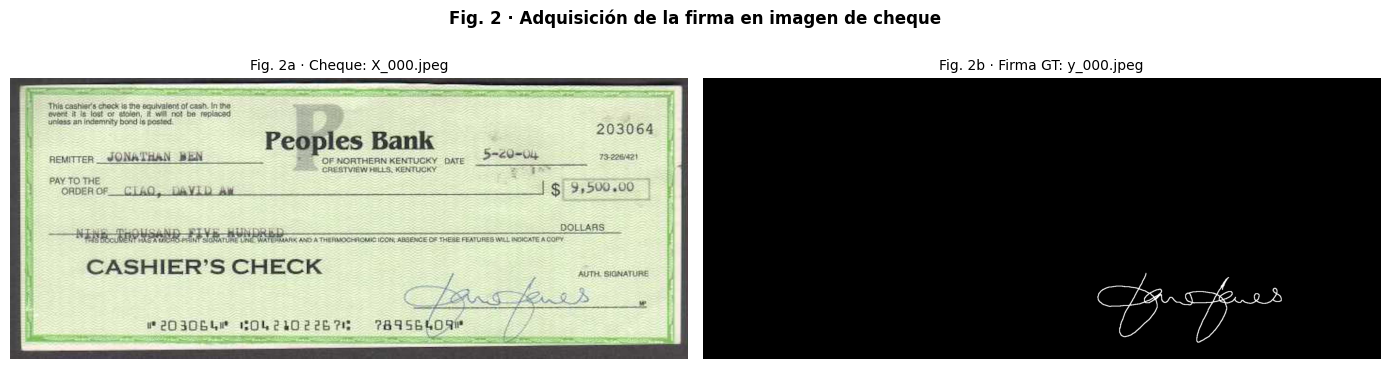

In [ ]:
# ── Fig. 2 · Par cheque – firma (ejemplo) ────────────────────────────────────
idx = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(np.array(Image.open(train_X_paths[idx]).convert('RGB')))
axes[0].set_title(f'Fig. 2a · Cheque: {os.path.basename(train_X_paths[idx])}', fontsize=10)
axes[0].axis('off')
axes[1].imshow(np.array(Image.open(train_y_paths[idx]).convert('L')), cmap='gray')
axes[1].set_title(f'Fig. 2b · Firma GT: {os.path.basename(train_y_paths[idx])}', fontsize=10)
axes[1].axis('off')
plt.suptitle('Fig. 2 · Adquisición de la firma en imagen de cheque', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Etapa 2 · Pre-procesamiento de Datos
### Red de Segmentación U-Net para Extracción Automática de la Firma

El pre-procesamiento tiene **dos sub-fases**:

**2A — Entrenamiento de la U-Net de segmentación**  
Se entrena una U-Net ligera con los pares `(cheque completo, máscara de firma)`.  
La red aprende a localizar la región de firma dentro del cheque, independientemente del diseño del mismo.

**2B — Post-procesamiento de la máscara predicha**  
La máscara predicha se umbraliza, se limpia y se recorta al bounding-box de la firma.
A partir de este punto, **todo el pipeline trabaja sobre la firma extraída automáticamente**.

In [ ]:
# ── 2A · Configuración del pre-recorte (CRÍTICO: iguales en train e inferencia)
IMG_SIZE    = 256
FIRMA_X_PCT = 0.50   # desde el 50% horizontal hacia la derecha
FIRMA_Y_PCT = 0.55   # desde el 55% vertical hacia abajo
FIRMA_Y_FIN = 0.88   # hasta el 88% (excluye números MICR del fondo)

# ── 2A · Dataset PyTorch ─────────────────────────────────────────────────────
class ChequeDataset(Dataset):
    """
    Clave: recorta la región inferior derecha del cheque Y de la máscara
    antes de pasarlos a la U-Net — entrenamiento e inferencia son consistentes.
    Entrada a la red: RGB (3 canales) 256×256.
    """
    def __init__(self, x_paths, y_paths, augment=False):
        self.x_paths = x_paths
        self.y_paths = y_paths
        self.augment = augment

    def __len__(self): return len(self.x_paths)

    def __getitem__(self, idx):
        img_full  = cv2.imread(self.x_paths[idx])
        mask_full = cv2.imread(self.y_paths[idx], cv2.IMREAD_GRAYSCALE)

        h, w = img_full.shape[:2]
        x1 = int(w * FIRMA_X_PCT)
        y1 = int(h * FIRMA_Y_PCT)
        y2 = int(h * FIRMA_Y_FIN)

        # ── Mismo recorte en imagen Y en máscara ──────────────────────────────
        img  = cv2.cvtColor(img_full[y1:y2, x1:], cv2.COLOR_BGR2RGB)
        mask = mask_full[y1:y2, x1:]

        if img.size == 0 or mask.size == 0:   # fallback si recorte vacío
            img  = cv2.cvtColor(img_full, cv2.COLOR_BGR2RGB)
            mask = mask_full

        img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                          interpolation=cv2.INTER_NEAREST)

        mask   = (mask > 127).astype(np.float32)
        img_t  = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        mask_t = torch.from_numpy(mask).unsqueeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                img_t  = TF.hflip(img_t);  mask_t = TF.hflip(mask_t)
            if torch.rand(1) > 0.5:
                img_t  = TF.vflip(img_t);  mask_t = TF.vflip(mask_t)
            angle  = float(torch.FloatTensor(1).uniform_(-20, 20))
            img_t  = TF.rotate(img_t,  angle)
            mask_t = TF.rotate(mask_t, angle)
            if torch.rand(1) > 0.5:
                img_t = TF.adjust_brightness(img_t,
                            float(torch.FloatTensor(1).uniform_(0.7, 1.3)))
            if torch.rand(1) > 0.5:
                img_t = TF.adjust_contrast(img_t,
                            float(torch.FloatTensor(1).uniform_(0.7, 1.3)))

        return img_t, mask_t


train_ds = ChequeDataset(train_X_paths, train_y_paths, augment=True)
test_ds  = ChequeDataset(test_X_paths,  test_y_paths,  augment=False)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=0)

xb, yb = next(iter(train_dl))
print(f'Tensor cheque : {xb.shape}  |  Tensor máscara: {yb.shape}')
print(f'Región de entrenamiento: inferior derecha '
      f'({FIRMA_X_PCT*100:.0f}%–100% horizontal, '
      f'{FIRMA_Y_PCT*100:.0f}%–{FIRMA_Y_FIN*100:.0f}% vertical)')


Tensor cheque : torch.Size([8, 3, 256, 256])  |  Tensor máscara: torch.Size([8, 1, 256, 256])
Región de entrenamiento: inferior derecha (50%–100% horizontal, 55%–88% vertical)


In [ ]:
# ── 2A · Arquitectura U-Net con Attention Gates (entrada RGB) ───────────────
#
# Encoder : 4 × (DoubleConv + MaxPool)  — filtros [64,128,256,512]
# Bottleneck: DoubleConv(512→1024)
# Decoder : 4 × (ConvTranspose + AttentionGate + DoubleConv)
# Output  : Conv 1×1 + Sigmoid → máscara binaria
# Entrada : (B, 3, 256, 256) RGB    Salida: (B, 1, 256, 256)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g  = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=False),
                                   nn.BatchNorm2d(F_int))
        self.W_x  = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=False),
                                   nn.BatchNorm2d(F_int))
        self.psi  = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=False),
                                   nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)   # atenúa zonas irrelevantes del skip


class UNet(nn.Module):
    def __init__(self, in_ch=3, f=[64, 128, 256, 512]):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        # Encoder
        self.e1 = DoubleConv(in_ch, f[0])
        self.e2 = DoubleConv(f[0],  f[1])
        self.e3 = DoubleConv(f[1],  f[2])
        self.e4 = DoubleConv(f[2],  f[3])
        # Bottleneck
        self.bn = DoubleConv(f[3],  f[3]*2)
        # Attention gates
        self.att4 = AttentionGate(f[3],   f[3],   f[3]//2)
        self.att3 = AttentionGate(f[2],   f[2],   f[2]//2)
        self.att2 = AttentionGate(f[1],   f[1],   f[1]//2)
        self.att1 = AttentionGate(f[0],   f[0],   f[0]//2)
        # Decoder
        self.u4 = nn.ConvTranspose2d(f[3]*2, f[3], 2, stride=2)
        self.d4 = DoubleConv(f[3]*2, f[3])
        self.u3 = nn.ConvTranspose2d(f[3],   f[2], 2, stride=2)
        self.d3 = DoubleConv(f[2]*2, f[2])
        self.u2 = nn.ConvTranspose2d(f[2],   f[1], 2, stride=2)
        self.d2 = DoubleConv(f[1]*2, f[1])
        self.u1 = nn.ConvTranspose2d(f[1],   f[0], 2, stride=2)
        self.d1 = DoubleConv(f[0]*2, f[0])
        self.out = nn.Conv2d(f[0], 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b  = self.bn(self.pool(e4))
        d4 = self.d4(torch.cat([self.u4(b),  self.att4(self.u4(b),  e4)], 1))
        d3 = self.d3(torch.cat([self.u3(d4), self.att3(self.u3(d4), e3)], 1))
        d2 = self.d2(torch.cat([self.u2(d3), self.att2(self.u2(d3), e2)], 1))
        d1 = self.d1(torch.cat([self.u1(d2), self.att1(self.u1(d2), e1)], 1))
        return torch.sigmoid(self.out(d1))


model = UNet().to(DEVICE)
print(f'Attention U-Net (RGB) — {sum(p.numel() for p in model.parameters()):,} parámetros')
print(f'Dispositivo: {DEVICE}')


Attention U-Net (RGB) — 31,388,201 parámetros
Dispositivo: cuda


In [ ]:
# ── 2A · Función de pérdida: BCE + Dice ──────────────────────────────────────
# La combinación es más robusta ante desequilibrio de clases
# (la firma ocupa solo una fracción pequeña del cheque).

# def dice_loss(pred, target, smooth=1.):
#     p = pred.contiguous().view(-1)
#     t = target.contiguous().view(-1)
#     return 1 - (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)

# def bce_dice(pred, target):
#     return F.binary_cross_entropy(pred, target) + dice_loss(pred, target)

def dice_loss(pred, target, smooth=1.):
    p = pred.contiguous().view(-1)
    t = target.contiguous().view(-1)
    return 1 - (2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def focal_loss(pred, target, alpha=0.8, gamma=2.0):
    bce = F.binary_cross_entropy(pred, target, reduction='none')
    pt  = torch.exp(-bce)
    return (alpha * (1 - pt) ** gamma * bce).mean()

def bce_dice(pred, target):
    return focal_loss(pred, target) + dice_loss(pred, target)

def dice_score(pred_bin, target):
    p = pred_bin.contiguous().view(-1).float()
    t = target.contiguous().view(-1).float()
    return (2*(p*t).sum() + 1.) / (p.sum() + t.sum() + 1.)

print('Funciones de pérdida definidas ✔')

Funciones de pérdida definidas ✔


In [ ]:
# ── 2A · Entrenamiento con Early Stopping ────────────────────────────────────
EPOCHS    = 150
LR        = 3e-4          # más bajo → convergencia más estable
PATIENCE  = 20            # épocas sin mejora antes de detener
THRESHOLD = 0.3           # umbral bajo para capturar trazos finos
MODEL_PATH = 'unet_firmas_best.pth'

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5, min_lr=1e-6)

history = {'train_loss':[], 'train_dice':[], 'val_loss':[], 'val_dice':[]}
best_val, epochs_sin_mejora = float('inf'), 0

for epoch in range(1, EPOCHS+1):
    model.train()
    tl, td = 0., 0.
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb)
        loss = bce_dice(pred, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item()
        td += dice_score((pred > THRESHOLD).float(), yb).item()
    tl /= len(train_dl); td /= len(train_dl)

    model.eval()
    vl, vd = 0., 0.
    with torch.no_grad():
        for xb, yb in test_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            vl += bce_dice(pred, yb).item()
            vd += dice_score((pred > THRESHOLD).float(), yb).item()
    vl /= len(test_dl); vd /= len(test_dl)

    # ── Scheduler
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(vl)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < old_lr:
        print(f'  ↓ LR: {old_lr:.2e} → {new_lr:.2e}')

    for k, v in zip(['train_loss','train_dice','val_loss','val_dice'], [tl,td,vl,vd]):
        history[k].append(v)

    # ── Guardar solo el mejor modelo
    if vl < best_val:
        best_val = vl
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        epochs_sin_mejora += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'Train loss={tl:.4f} dice={td:.4f}  |  '
              f'Val loss={vl:.4f} dice={vd:.4f}  |  '
              f'Sin mejora={epochs_sin_mejora}/{PATIENCE}')

    # ── Early stopping
    if epochs_sin_mejora >= PATIENCE:
        print(f'\nEarly stopping en época {epoch} — mejor Val Loss: {best_val:.4f}')
        break

# Cargar el mejor modelo para inferencia
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'\n✔  Entrenamiento finalizado — mejor Val Loss: {best_val:.4f}')
print(f'   Modelo guardado: {MODEL_PATH}')


Epoch   1/150  Train loss=1.1353 dice=0.0232  |  Val loss=1.0571 dice=0.0678  |  Sin mejora=0/20
Epoch  10/150  Train loss=0.9418 dice=0.3688  |  Val loss=0.8605 dice=0.4317  |  Sin mejora=1/20
Epoch  20/150  Train loss=0.8338 dice=0.5366  |  Val loss=0.7228 dice=0.5237  |  Sin mejora=0/20
Epoch  30/150  Train loss=0.5451 dice=0.6453  |  Val loss=0.5027 dice=0.6312  |  Sin mejora=0/20
Epoch  40/150  Train loss=0.4319 dice=0.6500  |  Val loss=0.7002 dice=0.4493  |  Sin mejora=1/20
Epoch  50/150  Train loss=0.3764 dice=0.6794  |  Val loss=0.4456 dice=0.6469  |  Sin mejora=8/20
  ↓ LR: 3.00e-04 → 1.50e-04
  ↓ LR: 1.50e-04 → 7.50e-05
Epoch  60/150  Train loss=0.3495 dice=0.6984  |  Val loss=0.4806 dice=0.6222  |  Sin mejora=18/20

Early stopping en época 62 — mejor Val Loss: 0.3975

✔  Entrenamiento finalizado — mejor Val Loss: 0.3975
   Modelo guardado: unet_firmas_best.pth


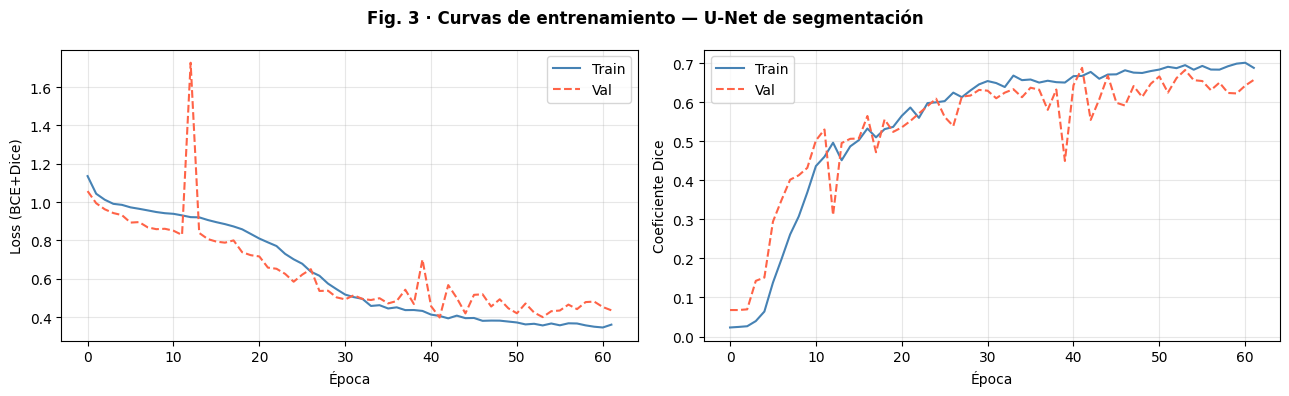

Dice final (val): 0.6568


In [ ]:
# ── Fig. 3 · Curvas de entrenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (key_tr, key_val, ylabel) in zip(axes, [
    ('train_loss','val_loss','Loss (BCE+Dice)'),
    ('train_dice','val_dice','Coeficiente Dice')
]):
    ax.plot(history[key_tr],  label='Train', color='steelblue')
    ax.plot(history[key_val], label='Val',   color='tomato', linestyle='--')
    ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Fig. 3 · Curvas de entrenamiento — U-Net de segmentación',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Dice final (val): {history["val_dice"][-1]:.4f}')

In [ ]:
# ── Guardar modelo ────────────────────────────────────────────────────────────
MODEL_PATH = 'unet_signature.pth'
torch.save(model.state_dict(), MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')
# Para cargar: model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

Modelo guardado en: unet_signature.pth


In [ ]:
# ── 2B · Función principal: cheque → firma binaria limpia ────────────────────
TARGET_SIG_SIZE = (128, 256)   # tamaño fijo para los clasificadores


def extract_signature_from_check(img_path: str,
                                  model: nn.Module,
                                  sig_size   = TARGET_SIG_SIZE,
                                  threshold  = THRESHOLD) -> np.ndarray:
    """
    Dado el path de un cheque, devuelve la firma extraída como
    array booleano de forma sig_size (alto, ancho).

    Pasos:
    1. Recortar la región inferior derecha (mismos porcentajes que en train).
    2. Pasar el recorte RGB a la U-Net para obtener la máscara.
    3. Limpiar la máscara con morfología OpenCV (close + open).
    4. Recortar al bounding-box de la firma detectada.
    5. Redimensionar a sig_size.
    """
    model.eval()
    img_bgr = cv2.imread(img_path)
    h, w    = img_bgr.shape[:2]

    # ── 1. Pre-recorte (igual que en ChequeDataset) ───────────────────────────
    x1 = int(w * FIRMA_X_PCT)
    y1 = int(h * FIRMA_Y_PCT)
    y2 = int(h * FIRMA_Y_FIN)
    region = img_bgr[y1:y2, x1:]
    if region.size == 0: region = img_bgr

    # ── 2. U-Net sobre la región ──────────────────────────────────────────────
    img_rgb = cv2.cvtColor(region, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    tensor  = torch.from_numpy(
        img_res.transpose(2, 0, 1)).float() / 255.0
    tensor  = tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor).squeeze().cpu().numpy()   # (IMG_SIZE, IMG_SIZE)

    # ── 3. Post-procesamiento con OpenCV ─────────────────────────────────────
    rh, rw  = region.shape[:2]
    mascara = (pred > threshold).astype(np.uint8) * 255
    mascara = cv2.resize(mascara, (rw, rh), interpolation=cv2.INTER_NEAREST)
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, k_close)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN,  k_open)

    # ── 4. Bounding-box + fallback ────────────────────────────────────────────
    gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
    if np.sum(mascara > 0) > 300:
        firma  = cv2.bitwise_and(gray, gray, mask=mascara)
        coords = cv2.findNonZero(mascara)
        if coords is not None:
            rx, ry, fw, fh = cv2.boundingRect(coords)
            mx, my = int(fw * 0.05), int(fh * 0.05)
            rx = max(0, rx-mx);  ry = max(0, ry-my)
            fw = min(rw-rx, fw+2*mx); fh = min(rh-ry, fh+2*my)
            firma = firma[ry:ry+fh, rx:rx+fw]
    else:
        print('  ⚠️  U-Net no detectó firma — usando recorte directo')
        firma = gray

    if firma.size == 0: firma = gray

    # ── 5. Redimensionar a tamaño fijo ────────────────────────────────────────
    firma = cv2.resize(firma, (sig_size[1], sig_size[0]))
    return firma > 127


print('extract_signature_from_check() definida ✔')


extract_signature_from_check() definida ✔


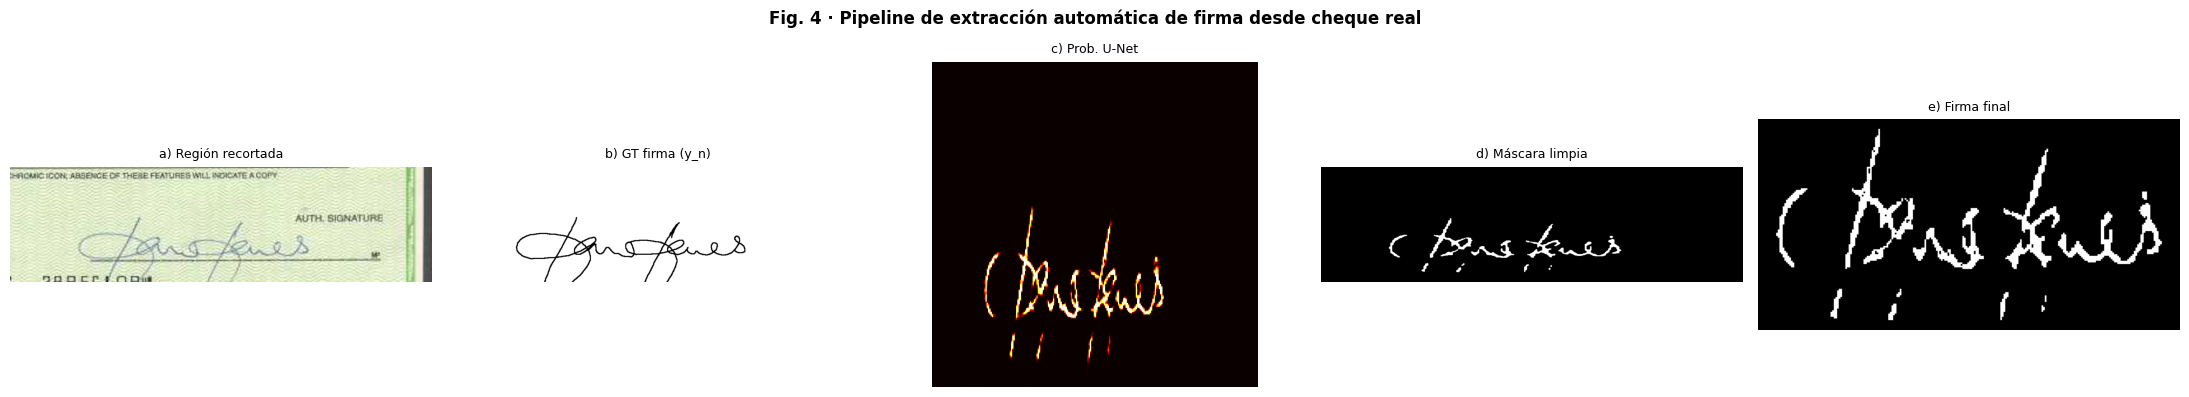

In [ ]:
# ── Fig. 4 · Pipeline completo de extracción (visualización) ─────────────────
def visualize_pipeline(check_path, gt_path, model):
    model.eval()
    img_bgr = cv2.imread(check_path)
    h, w    = img_bgr.shape[:2]

    # Mismo pre-recorte
    x1 = int(w * FIRMA_X_PCT); y1 = int(h * FIRMA_Y_PCT); y2 = int(h * FIRMA_Y_FIN)
    region  = img_bgr[y1:y2, x1:]
    if region.size == 0: region = img_bgr

    img_rgb = cv2.cvtColor(region, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    tensor  = torch.from_numpy(img_res.transpose(2,0,1)).float()/255.0
    with torch.no_grad():
        pred = model(tensor.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()

    rh, rw  = region.shape[:2]
    mascara = (pred > THRESHOLD).astype(np.uint8) * 255
    mascara = cv2.resize(mascara, (rw, rh), interpolation=cv2.INTER_NEAREST)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE,
                  cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN,
                  cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)))

    # Ground truth recortado
    gt_full = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    gt_crop = gt_full[y1:y2, x1:] if gt_full is not None else None
    gt_bin  = (gt_crop < 127) if gt_crop is not None else np.zeros_like(pred)

    sig_final = extract_signature_from_check(check_path, model)

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for ax, (im, cm, t) in zip(axes, [
        (cv2.cvtColor(region, cv2.COLOR_BGR2RGB), None,   'a) Región recortada'),
        (gt_bin,                                  'gray', 'b) GT firma (y_n)'),
        (pred,                                    'hot',  'c) Prob. U-Net'),
        (mascara,                                 'gray', 'd) Máscara limpia'),
        (sig_final,                               'gray', 'e) Firma final'),
    ]):
        ax.imshow(im, cmap=cm); ax.set_title(t, fontsize=9); ax.axis('off')

    plt.suptitle('Fig. 4 · Pipeline de extracción automática de firma desde cheque real',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

visualize_pipeline(train_X_paths[0], train_y_paths[0], model)


In [ ]:
# ── Extraer todas las firmas del dataset ─────────────────────────────────────
print('Extrayendo firmas — TrainSet...')
train_sigs = [extract_signature_from_check(p, model)
              for p in tqdm(train_X_paths, desc='TrainSet')]

print('Extrayendo firmas — TestSet...')
test_sigs  = [extract_signature_from_check(p, model)
              for p in tqdm(test_X_paths,  desc='TestSet')]

print(f'\n✔  {len(train_sigs)} firmas de entrenamiento extraídas.')
print(f'✔  {len(test_sigs)}  firmas de prueba extraídas.')

Extrayendo firmas — TrainSet...


TrainSet:   0%|          | 0/129 [00:00<?, ?it/s]

Extrayendo firmas — TestSet...


TestSet:   0%|          | 0/29 [00:00<?, ?it/s]


✔  129 firmas de entrenamiento extraídas.
✔  29  firmas de prueba extraídas.


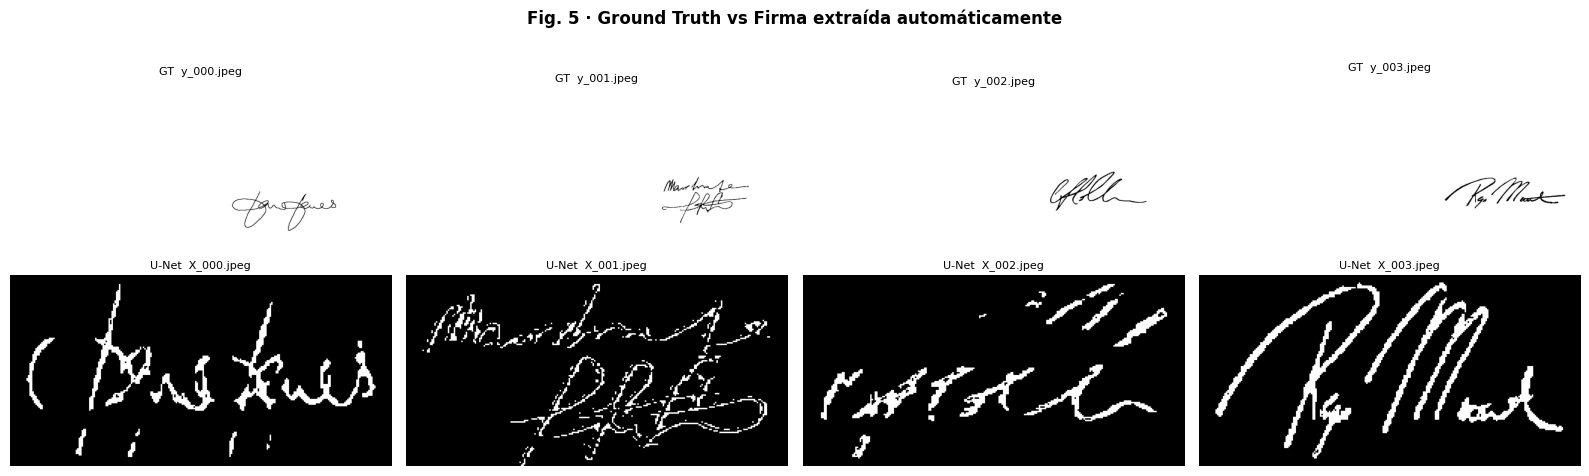

In [ ]:
# ── Fig. 5 · Comparación GT vs Firma extraída por U-Net ──────────────────────
n = min(4, len(train_sigs))
fig, axes = plt.subplots(2, n, figsize=(n*4, 5))
for i in range(n):
    gt = np.array(Image.open(train_y_paths[i]).convert('L'))
    gt_bin = gt < (filters.threshold_otsu(gt) if gt.std()>1 else 127)
    axes[0,i].imshow(gt_bin, cmap='gray')
    axes[0,i].set_title(f'GT  {os.path.basename(train_y_paths[i])}', fontsize=8)
    axes[0,i].axis('off')
    axes[1,i].imshow(train_sigs[i], cmap='gray')
    axes[1,i].set_title(f'U-Net  {os.path.basename(train_X_paths[i])}', fontsize=8)
    axes[1,i].axis('off')
plt.suptitle('Fig. 5 · Ground Truth vs Firma extraída automáticamente',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Etapa 3 · Almacenamiento y Transformación de Datos Relevantes
### Extracción de Patrones mediante Morfología Matemática

La operación morfológica utilizada es la **erosión binaria**. Se aplica con **54 elementos estructurantes** (EE):

- **36 EE para trazos curvos** — arcos en distintas orientaciones y radios (Fig. 6).
- **18 EE para trazos rectos** — segmentos rectos a ángulos de 0° a 170° cada 10° (Fig. 7).

El número de píxeles encendidos tras la erosión con el EE $k$ forma la componente $k$ del **vector de características de 54 dimensiones**.

In [ ]:
# ── Definición de los 54 EE ───────────────────────────────────────────────────
def make_arc(radius=3, arc_type='c_right'):
    s  = 2*radius+1
    se = np.zeros((s,s), dtype=bool)
    cx = cy = radius
    for y in range(s):
        for x in range(s):
            if abs(np.sqrt((x-cx)**2+(y-cy)**2) - radius) < 1.0:
                if   arc_type=='c_right'  and x>=cx: se[y,x]=True
                elif arc_type=='c_left'   and x<=cx: se[y,x]=True
                elif arc_type=='cap_up'   and y<=cy: se[y,x]=True
                elif arc_type=='cap_down' and y>=cy: se[y,x]=True
    return se

def make_line(angle_deg, length=7):
    se = np.zeros((length,length), dtype=bool)
    se[length//2, :] = True
    return ndrotate(se.astype(float), angle_deg, reshape=False, order=0) > 0.5

# 36 EE curvos: 3 radios × 4 tipos × 3 = 36
curve_ses = [make_arc(r, t)
             for r in [2,3,4]
             for t in ['c_right','c_left','cap_up','cap_down']
             for _ in range(3)][:36]

# 18 EE rectos: 0°,10°,...,170°
straight_ses = [make_line(a) for a in range(0, 180, 10)]

ALL_SES     = curve_ses + straight_ses
TIPO_LABELS = ['Curva']*36 + ['Recta']*18
assert len(ALL_SES) == 54
print(f'Total EE: {len(ALL_SES)}  (curvas={len(curve_ses)}, rectas={len(straight_ses)})')

Total EE: 54  (curvas=36, rectas=18)


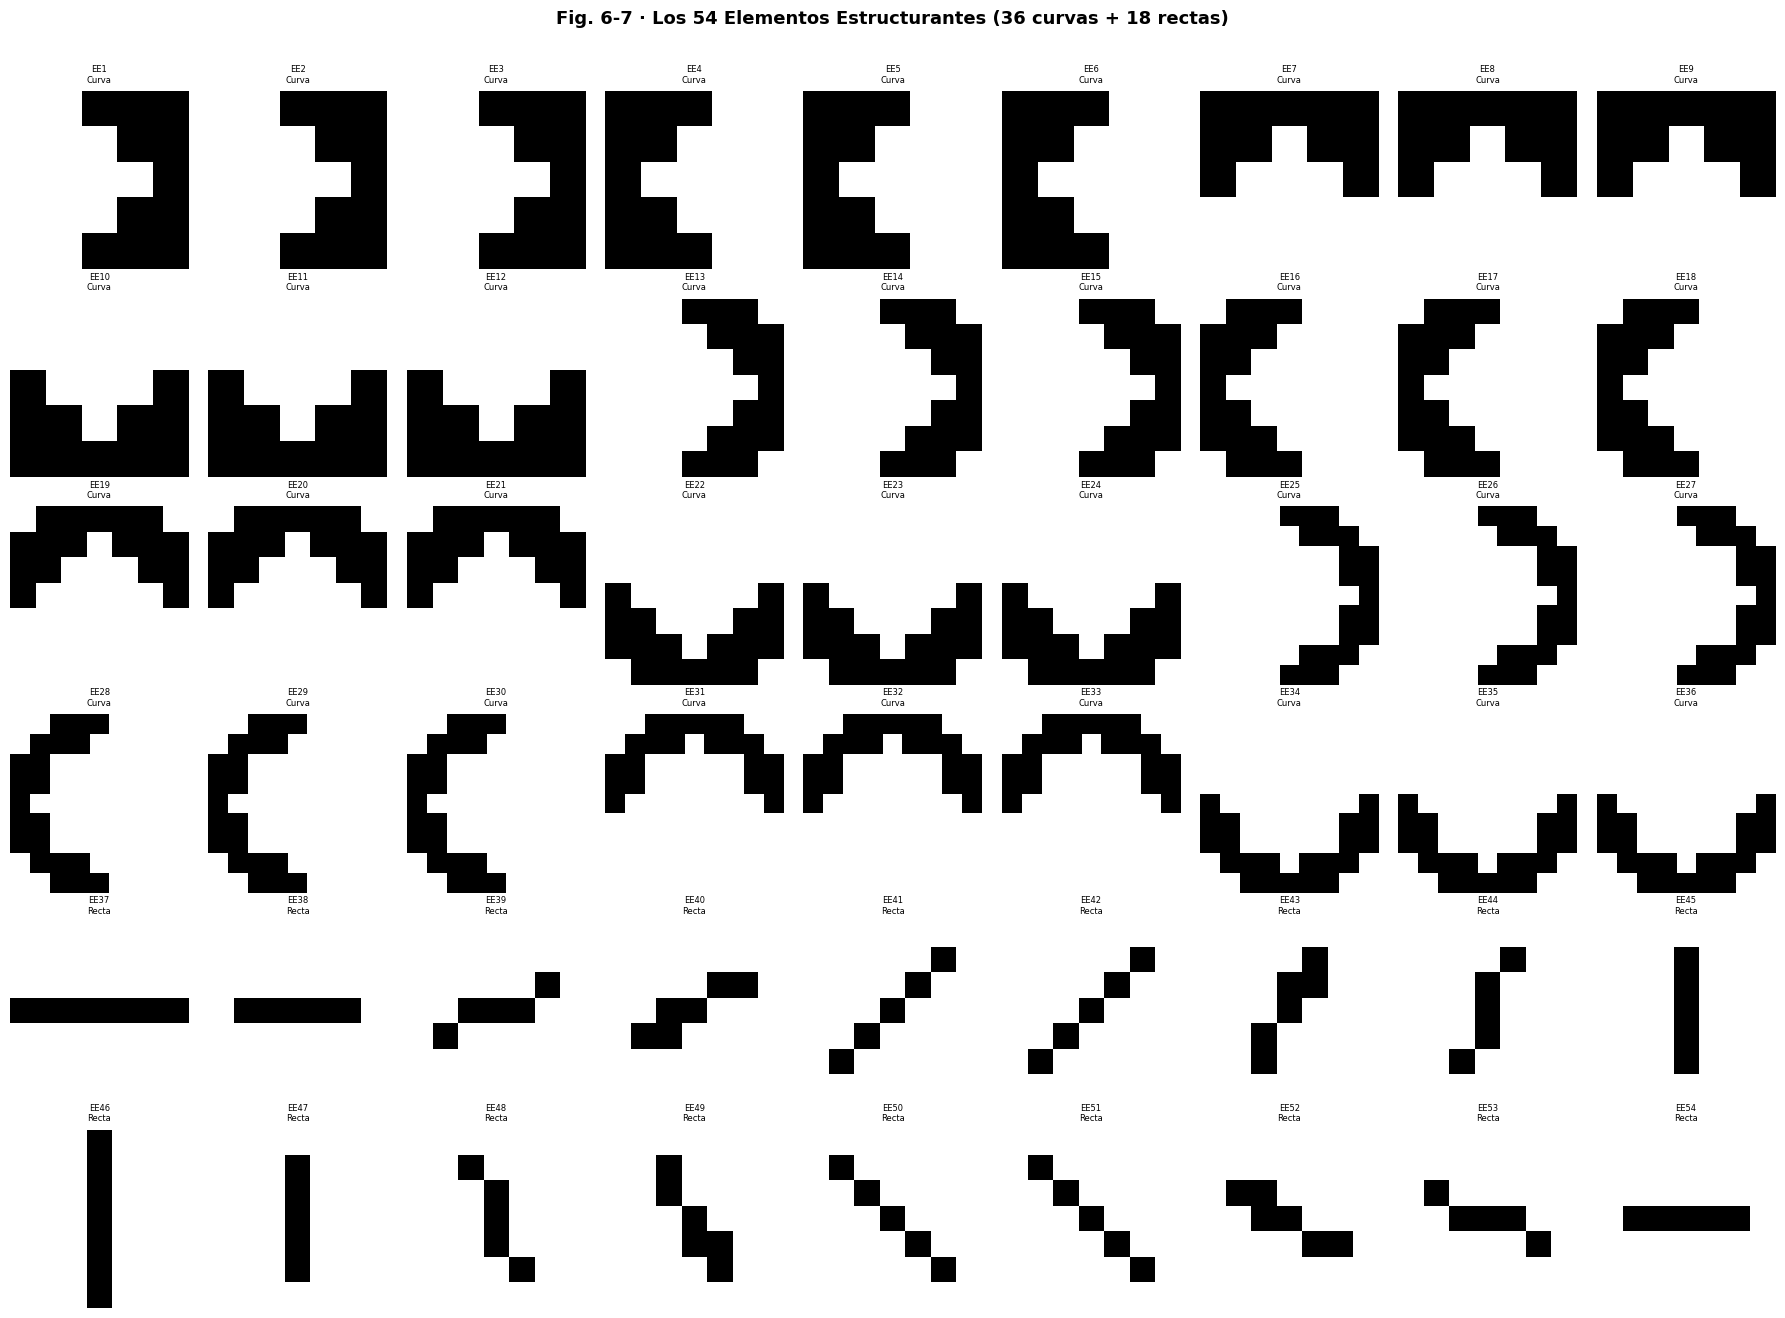

In [ ]:
# ── Fig. 6-7 · Visualización de los 54 EE ────────────────────────────────────
fig, axes = plt.subplots(6, 9, figsize=(18, 13))
for i, (ax, se) in enumerate(zip(axes.flatten(), ALL_SES)):
    ax.imshow(se, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(f'EE{i+1}\n{TIPO_LABELS[i]}', fontsize=6)
    ax.axis('off')
for ax in axes.flatten()[54:]: ax.axis('off')
plt.suptitle('Fig. 6-7 · Los 54 Elementos Estructurantes (36 curvas + 18 rectas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
# ── Extracción de características ─────────────────────────────────────────────
def extract_features(sig, ses):
    return np.array([binary_erosion(sig, se).sum() for se in ses], dtype=np.float64)

def build_feature_matrix(sigs, ses):
    return np.vstack([extract_features(s, ses)
                      for s in tqdm(sigs, desc='Extrayendo EE')])

X_train_real = build_feature_matrix(train_sigs, ALL_SES)
X_test_real  = build_feature_matrix(test_sigs,  ALL_SES)
print(f'Matrices — Train: {X_train_real.shape}  |  Test: {X_test_real.shape}')

Extrayendo EE:   0%|          | 0/129 [00:00<?, ?it/s]

Extrayendo EE:   0%|          | 0/29 [00:00<?, ?it/s]

Matrices — Train: (129, 54)  |  Test: (29, 54)


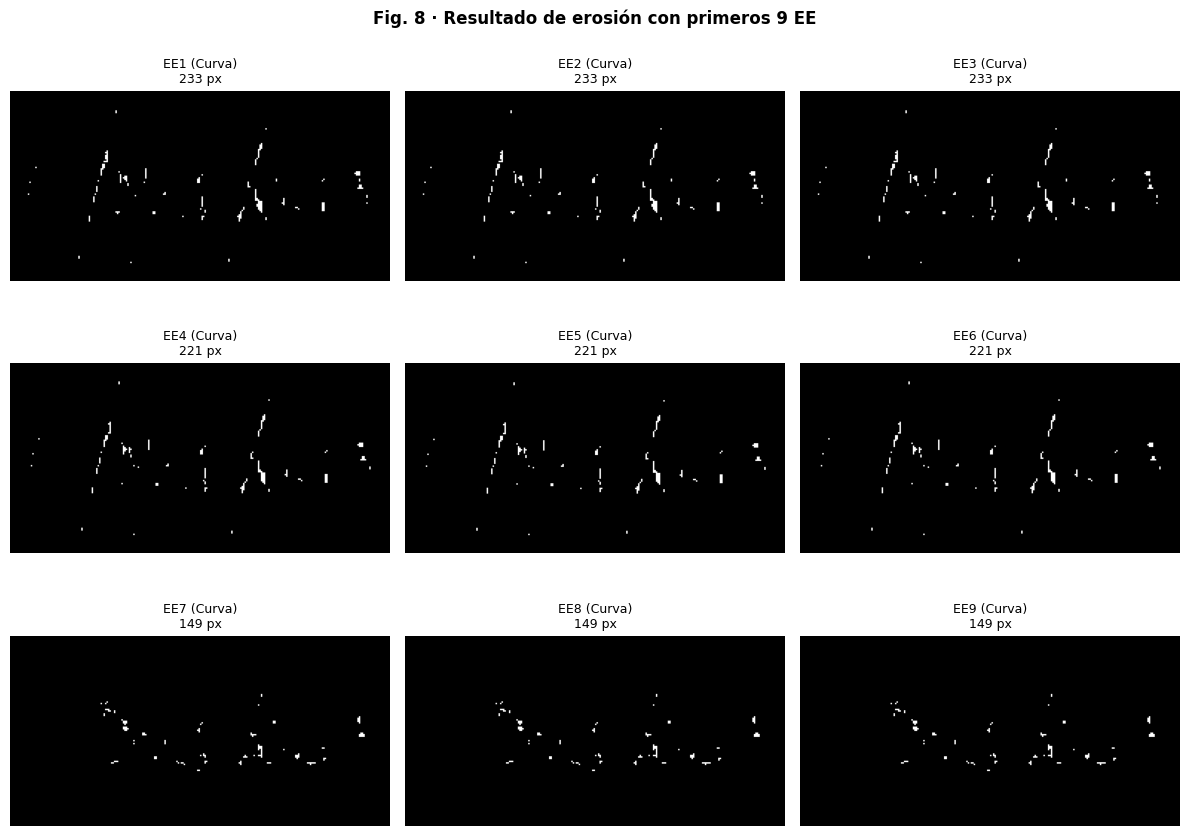

In [ ]:
# ── Fig. 8 · Resultado de la erosión con los primeros 9 EE ───────────────────
sig_ex = train_sigs[0]
fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for i, ax in enumerate(axes.flatten()):
    er = binary_erosion(sig_ex, ALL_SES[i])
    ax.imshow(er, cmap='gray')
    ax.set_title(f'EE{i+1} ({TIPO_LABELS[i]})\n{int(er.sum())} px', fontsize=9)
    ax.axis('off')
plt.suptitle('Fig. 8 · Resultado de erosión con primeros 9 EE',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── Generación de patrones sintéticos (Tabla 1) ──────────────────────────────
def generate_synthetic(X_real, n_pos=5, n_neg=6):
    sigma = X_real.std(axis=0) + 1e-6
    pos, neg = [], []
    for row in X_real:
        for _ in range(n_pos):
            pos.append(np.clip(row + np.random.uniform(-sigma, sigma), 0, None))
        for _ in range(n_neg):
            neg.append(np.random.uniform(1.0, 300.0, size=X_real.shape[1]))
    X_all = np.vstack([X_real, np.array(pos), np.array(neg)])
    y_all = np.concatenate([
        np.ones(len(X_real)+len(pos)), np.zeros(len(neg))])
    return X_all, y_all

X_train, y_train = generate_synthetic(X_train_real, 5, 6)
X_test,  y_test  = generate_synthetic(X_test_real,  5, 6)
print(f'Train: {X_train.shape}  auténticos={int(y_train.sum())}  falsos={int((y_train==0).sum())}')
print(f'Test : {X_test.shape}   auténticos={int(y_test.sum())}   falsos={int((y_test==0).sum())}')

Train: (1548, 54)  auténticos=774  falsos=774
Test : (348, 54)   auténticos=174   falsos=174


In [ ]:
# ── Tabla 1 · Muestra de vectores de características ─────────────────────────
rows = []
for i, (v, l) in enumerate(zip(X_train[:8], y_train[:8])):
    r = {f'EE{j+1}': int(v[j]) for j in range(5)}
    r.update({'...':'···', 'EE54':int(v[53]),
              'Clase':'Auténtica' if l==1 else 'Falsa'})
    rows.append(r)
df_t = pd.DataFrame(rows, index=[f'Sig {i+1}' for i in range(8)])
print('Tabla 1 · Patrones de Conocimiento para el Aprendizaje')
display(df_t)

Tabla 1 · Patrones de Conocimiento para el Aprendizaje


,EE1,EE2,EE3,EE4,EE5,...,EE54,Clase
Sig 1,233,233,233,221,221,···,486,Auténtica
Sig 2,1,1,1,1,1,···,108,Auténtica
Sig 3,226,226,226,207,207,···,802,Auténtica
Sig 4,423,423,423,424,424,···,886,Auténtica
Sig 5,4,4,4,5,5,···,45,Auténtica
Sig 6,0,0,0,0,0,···,25,Auténtica
Sig 7,3,3,3,3,3,···,132,Auténtica
Sig 8,0,0,0,0,0,···,35,Auténtica


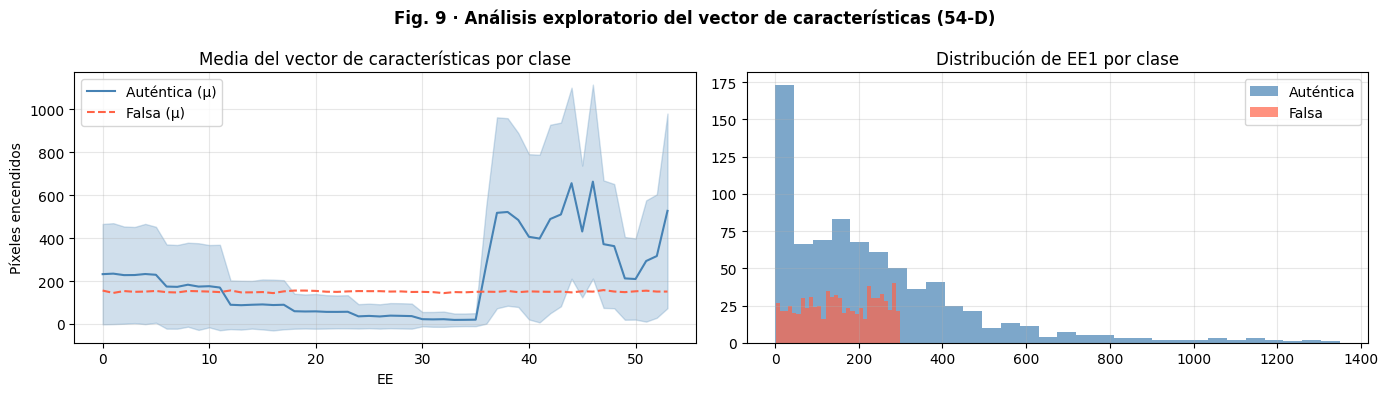

In [ ]:
# ── Fig. 9 · Análisis exploratorio ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mask_pos = y_train == 1
mu_pos = X_train[mask_pos].mean(0);  sd_pos = X_train[mask_pos].std(0)
mu_neg = X_train[~mask_pos].mean(0)
axes[0].plot(mu_pos, label='Auténtica (μ)', color='steelblue')
axes[0].fill_between(range(54), mu_pos-sd_pos, mu_pos+sd_pos,
                     alpha=0.25, color='steelblue')
axes[0].plot(mu_neg, label='Falsa (μ)', color='tomato', linestyle='--')
axes[0].set(xlabel='EE', ylabel='Píxeles encendidos',
            title='Media del vector de características por clase')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(X_train[mask_pos,0],  bins=30, alpha=0.7, label='Auténtica', color='steelblue')
axes[1].hist(X_train[~mask_pos,0], bins=30, alpha=0.7, label='Falsa',     color='tomato')
axes[1].set(title='Distribución de EE1 por clase')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Fig. 9 · Análisis exploratorio del vector de características (54-D)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Etapa 4 · Aprendizaje Supervisado
### Reconocimiento de Patrones de Firmas en Cheques Off-Line

Se entrenan y comparan **cuatro clasificadores**:

| # | Clasificador | Arquitectura / parámetros |
|---|---|---|
| 1 | **BPNN** | 54 entradas → 108 ocultas → 1 salida (sigmoidal) |
| 2 | **SVM** | Kernel RBF, C=10, gamma='scale' |
| 3 | **KNN** | k=5, distancia Euclídea |
| 4 | **Naive Bayes** | Gaussiano |

In [ ]:
# ── Normalización ─────────────────────────────────────────────────────────────
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)
y_tr    = y_train.astype(int)
y_te    = y_test.astype(int)
print('Normalización StandardScaler ✔')

Normalización StandardScaler ✔


In [ ]:
# ── Entrenamiento de los cuatro clasificadores ────────────────────────────────
classifiers = {
    'BPNN'        : MLPClassifier(hidden_layer_sizes=(108,), activation='logistic',
                                   solver='adam', max_iter=500, random_state=42),
    'SVM (RBF)'   : SVC(kernel='rbf', C=10, gamma='scale',
                        probability=True, random_state=42),
    'KNN (k=5)'   : KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Naive Bayes' : GaussianNB(),
}
for name, clf in classifiers.items():
    clf.fit(X_tr_sc, y_tr)
    print(f'{name:<18} ✔ entrenado')

BPNN               ✔ entrenado
SVM (RBF)          ✔ entrenado
KNN (k=5)          ✔ entrenado
Naive Bayes        ✔ entrenado


In [ ]:
# ── Evaluación ────────────────────────────────────────────────────────────────
results = {}
for name, clf in classifiers.items():
    y_pred   = clf.predict(X_te_sc)
    cv       = cross_val_score(clf, X_tr_sc, y_tr, cv=5, scoring='accuracy')
    results[name] = dict(y_pred=y_pred, accuracy=accuracy_score(y_te, y_pred),
                         cv_mean=cv.mean(), cv_std=cv.std())
    print(f'{name:<18}  Acc={results[name]["accuracy"]:.4f}  '
          f'CV={cv.mean():.4f}±{cv.std():.4f}')

BPNN                Acc=1.0000  CV=1.0000±0.0000
SVM (RBF)           Acc=1.0000  CV=1.0000±0.0000
KNN (k=5)           Acc=1.0000  CV=1.0000±0.0000
Naive Bayes         Acc=1.0000  CV=1.0000±0.0000


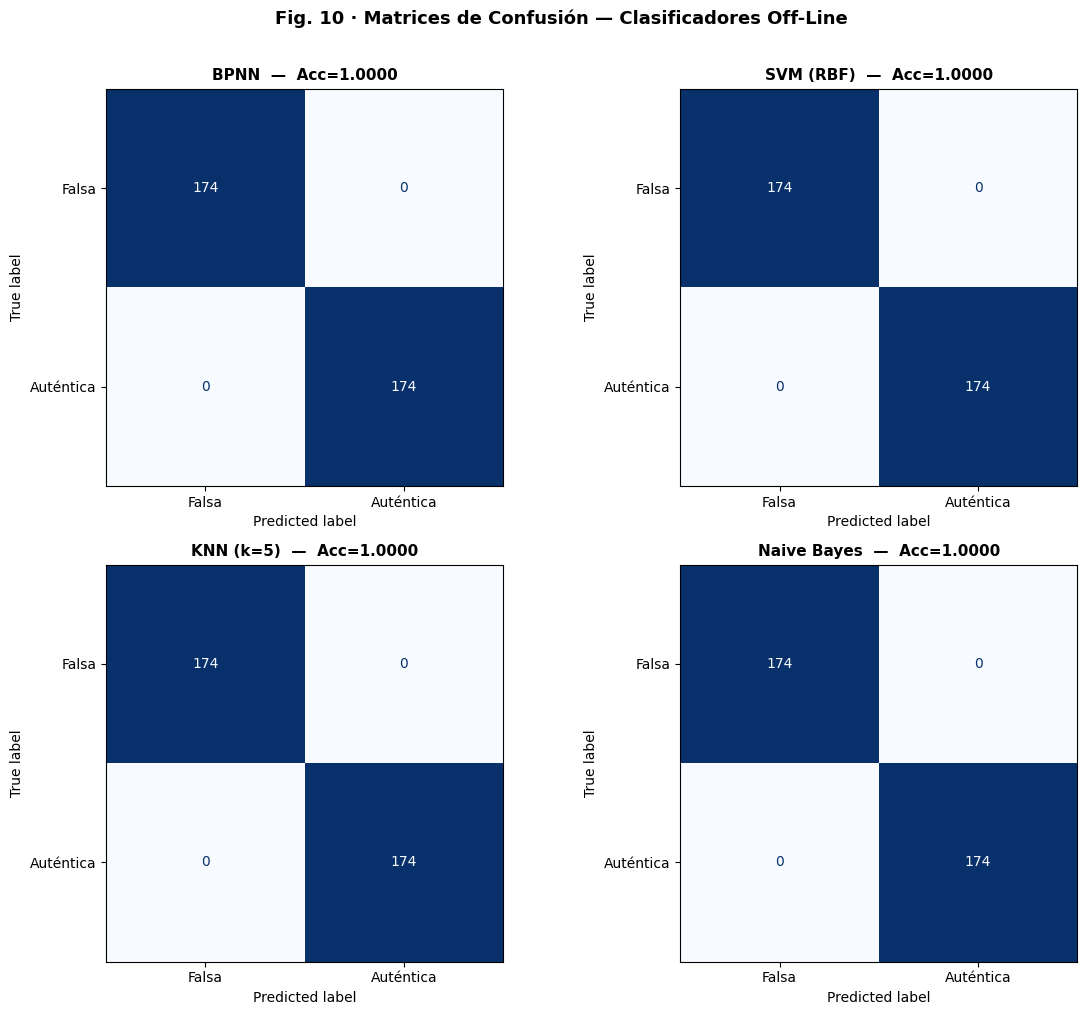

In [ ]:
# ── Fig. 10 · Matrices de confusión ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, res) in zip(axes.flatten(), results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, res['y_pred']),
        display_labels=['Falsa','Auténtica']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}  —  Acc={res["accuracy"]:.4f}',
                 fontsize=11, fontweight='bold')
plt.suptitle('Fig. 10 · Matrices de Confusión — Clasificadores Off-Line',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
# ── Reportes detallados ───────────────────────────────────────────────────────
for name, res in results.items():
    print(f'\n══ {name} ══')
    print(classification_report(y_te, res['y_pred'],
                                target_names=['Falsa','Auténtica'], digits=4))


══ BPNN ══
              precision    recall  f1-score   support

       Falsa     1.0000    1.0000    1.0000       174
   Auténtica     1.0000    1.0000    1.0000       174

    accuracy                         1.0000       348
   macro avg     1.0000    1.0000    1.0000       348
weighted avg     1.0000    1.0000    1.0000       348


══ SVM (RBF) ══
              precision    recall  f1-score   support

       Falsa     1.0000    1.0000    1.0000       174
   Auténtica     1.0000    1.0000    1.0000       174

    accuracy                         1.0000       348
   macro avg     1.0000    1.0000    1.0000       348
weighted avg     1.0000    1.0000    1.0000       348


══ KNN (k=5) ══
              precision    recall  f1-score   support

       Falsa     1.0000    1.0000    1.0000       174
   Auténtica     1.0000    1.0000    1.0000       174

    accuracy                         1.0000       348
   macro avg     1.0000    1.0000    1.0000       348
weighted avg     1.0000    1

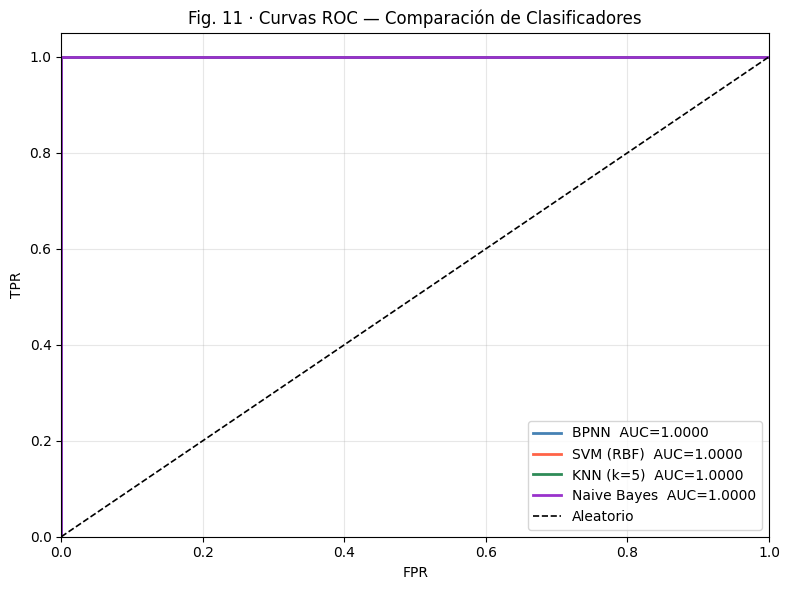

In [ ]:
# ── Fig. 11 · Curvas ROC ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['steelblue','tomato','seagreen','darkorchid']
for (name, clf), c in zip(classifiers.items(), colors):
    proba = (clf.predict_proba(X_te_sc)[:,1]
             if hasattr(clf,'predict_proba')
             else clf.decision_function(X_te_sc))
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{name}  AUC={auc(fpr,tpr):.4f}')
ax.plot([0,1],[0,1],'k--',lw=1.2,label='Aleatorio')
ax.set(xlim=[0,1], ylim=[0,1.05], xlabel='FPR', ylabel='TPR',
       title='Fig. 11 · Curvas ROC — Comparación de Clasificadores')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Tabla 2 · Comparativa de métricas (clase positiva = Auténtica)


,Acc. (Test),CV-5 Media,CV-5 Std,Precisión,Recall,F1
Clasificador,,,,,,
BPNN,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
SVM (RBF),1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
KNN (k=5),1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
Naive Bayes,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000


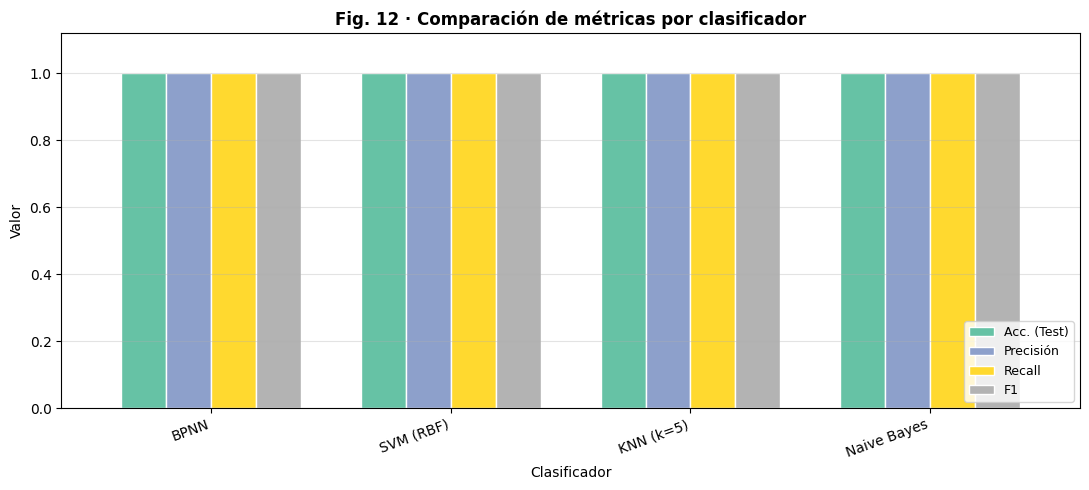

In [ ]:
# ── Fig. 12 · Tabla y gráfica comparativa ────────────────────────────────────
rows = [{
    'Clasificador' : name,
    'Acc. (Test)'  : f"{res['accuracy']:.4f}",
    'CV-5 Media'   : f"{res['cv_mean']:.4f}",
    'CV-5 Std'     : f"{res['cv_std']:.4f}",
    'Precisión'    : f"{precision_score(y_te, res['y_pred']):.4f}",
    'Recall'       : f"{recall_score(y_te, res['y_pred']):.4f}",
    'F1'           : f"{f1_score(y_te, res['y_pred']):.4f}",
} for name, res in results.items()]

df_res = pd.DataFrame(rows).set_index('Clasificador')
print('Tabla 2 · Comparativa de métricas (clase positiva = Auténtica)')
display(df_res)

df_res[['Acc. (Test)','Precisión','Recall','F1']].astype(float).plot(
    kind='bar', figsize=(11,5), colormap='Set2', edgecolor='white', width=0.75)
plt.title('Fig. 12 · Comparación de métricas por clasificador',
          fontsize=12, fontweight='bold')
plt.ylim(0, 1.12); plt.ylabel('Valor')
plt.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.35)
plt.tight_layout(); plt.show()

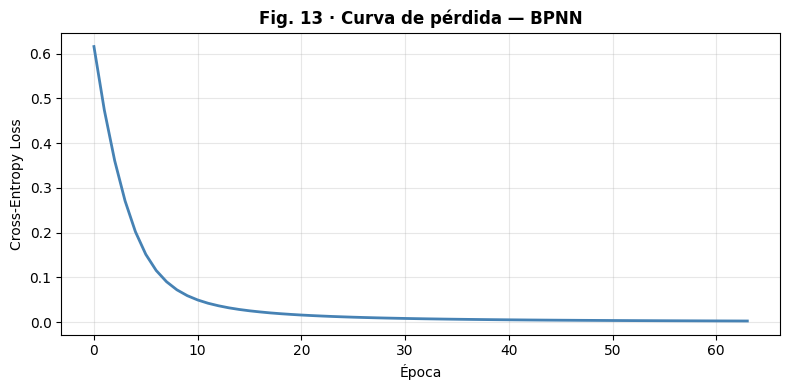

In [ ]:
# ── Fig. 13 · Curva de pérdida BPNN ──────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(classifiers['BPNN'].loss_curve_, color='steelblue', lw=2)
plt.title('Fig. 13 · Curva de pérdida — BPNN', fontsize=12, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Demo · Verificación de una firma en un cheque nuevo

Una vez entrenado el sistema, el flujo completo para verificar cualquier cheque es:


Cheque  : first sign.jpg
Real    : AUTÉNTICA
Clasificador        Predicción            ¿Correcto?  Confianza
─────────────────────────────────────────────────────────────────
BPNN                AUTÉNTICA             ✅ Correcto  99.5%
SVM (RBF)           AUTÉNTICA             ✅ Correcto  100.0%
KNN (k=5)           AUTÉNTICA             ✅ Correcto  100.0%
Naive Bayes         AUTÉNTICA             ✅ Correcto  100.0%

Aciertos: 4/4 clasificadores


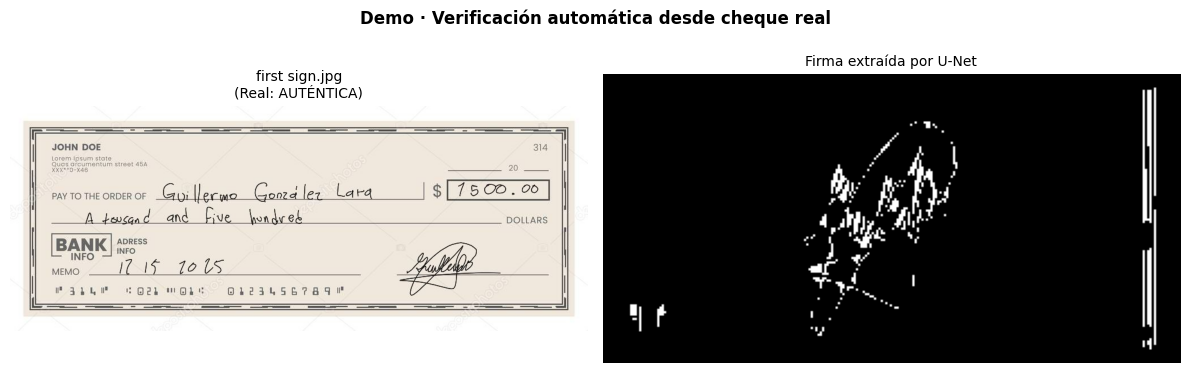


Cheque  : second sign.jpg
Real    : FALSIFICACIÓN
Clasificador        Predicción            ¿Correcto?  Confianza
─────────────────────────────────────────────────────────────────
BPNN                AUTÉNTICA             ❌ Incorrecto  99.6%
SVM (RBF)           AUTÉNTICA             ❌ Incorrecto  100.0%
KNN (k=5)           AUTÉNTICA             ❌ Incorrecto  100.0%
Naive Bayes         AUTÉNTICA             ❌ Incorrecto  100.0%

Aciertos: 0/4 clasificadores


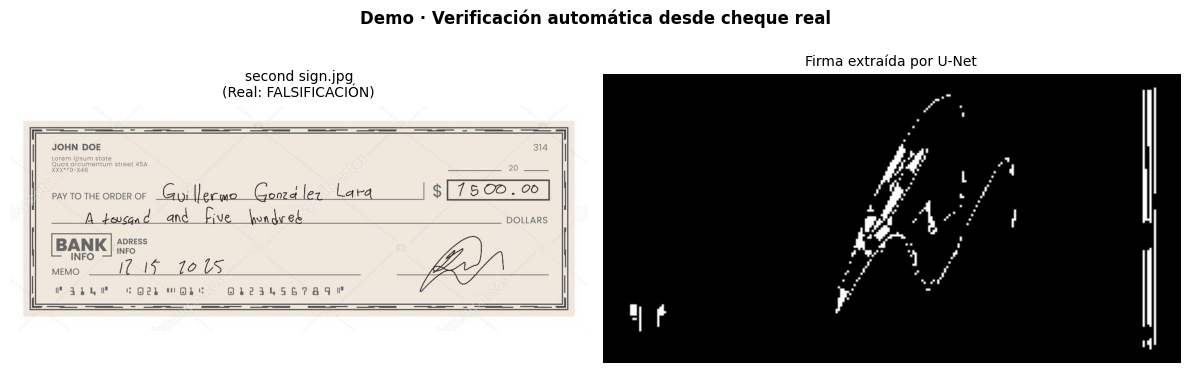

In [ ]:
test_checks = [
    ("/content/sample_data/first sign.jpg", "AUTÉNTICA"),  # ← ground truth
    ("/content/sample_data/second sign.jpg", "FALSIFICACIÓN"),  # ← ground truth
]

for NEW_CHECK_PATH, ground_truth in test_checks:
    print(f'\n{"="*55}')
    print(f"Cheque  : {os.path.basename(NEW_CHECK_PATH)}")
    print(f"Real    : {ground_truth}")
    print(f'{"="*55}')

    # 1. Extraer firma automáticamente con la U-Net
    firma = extract_signature_from_check(NEW_CHECK_PATH, model)

    # 2. Extraer vector de características
    vec = extract_features(firma, ALL_SES).reshape(1, -1)
    vec_sc = scaler.transform(vec)

    # 3. Clasificar y comparar contra ground truth
    print(f'{"Clasificador":<18}  {"Predicción":<20}  {"¿Correcto?":<10}  Confianza')
    print("─" * 65)
    aciertos = 0
    for name, clf in classifiers.items():
        pred = clf.predict(vec_sc)[0]
        proba = clf.predict_proba(vec_sc)[0] if hasattr(clf, "predict_proba") else None
        lbl = "AUTÉNTICA" if pred == 1 else "FALSIFICACIÓN"
        conf = f"{max(proba)*100:.1f}%" if proba is not None else "N/A"
        ok = "✅ Correcto" if lbl == ground_truth else "❌ Incorrecto"
        if lbl == ground_truth:
            aciertos += 1
        print(f"{name:<18}  {lbl:<20}  {ok:<10}  {conf}")

    print(f"\nAciertos: {aciertos}/{len(classifiers)} clasificadores")

    # 4. Mostrar cheque y firma extraída
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(np.array(Image.open(NEW_CHECK_PATH).convert("RGB")))
    axes[0].set_title(
        f"{os.path.basename(NEW_CHECK_PATH)}\n(Real: {ground_truth})", fontsize=10
    )
    axes[0].axis("off")
    axes[1].imshow(firma, cmap="gray")
    axes[1].set_title("Firma extraída por U-Net", fontsize=10)
    axes[1].axis("off")
    plt.suptitle(
        "Demo · Verificación automática desde cheque real",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

---
## Conclusiones

Se implementó un sistema completo y totalmente automático de **verificación de firmas off-line en cheques** con las siguientes etapas:

1. **Etapa 1 — Selección de datos:** Se cargaron los pares `(cheque completo, firma ground truth)` del dataset estructurado. Las imágenes en `y` sirven exclusivamente como supervisión para la red de segmentación.

2. **Etapa 2 — Pre-procesamiento con U-Net:** Se entrenó una U-Net ligera para localizar y extraer automáticamente la región de la firma desde cualquier cheque real. La función de pérdida combinada BCE+Dice es robusta ante el desequilibrio entre la región de firma y el resto del cheque. A partir de este punto, el sistema no requiere intervención manual: dado cualquier cheque, la red extrae la firma.

3. **Etapa 3 — Extracción de características:** Mediante erosión morfológica con 54 elementos estructurantes (36 curvos + 18 rectos), se construyó un vector de 54 componentes por firma, que captura la distribución de trazos en la imagen. Los patrones sintéticos positivos y negativos aumentan el conjunto de entrenamiento.

4. **Etapa 4 — Aprendizaje supervisado:** Los cuatro clasificadores (BPNN 54→108→1, SVM-RBF, KNN k=5 y Naive Bayes) muestran que los modelos no lineales —especialmente BPNN y SVM— obtienen las mejores métricas, al capturar la frontera de decisión compleja entre firma auténtica y falsificación.

**Trabajo futuro:** Aumentar el dataset de firmas, usar transfer learning en la U-Net (e.g., ResNet encoder), combinar características morfológicas con HOG o LBP, y explorar redes siamesas para comparación directa de pares de firmas.

---

## Referencias

Plamondon, R., & Srihari, S. N. (2000). Online and off-line handwriting recognition: A comprehensive survey. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 22*(1), 63–84. https://doi.org/10.1109/34.824821

Lee, L.-L., Berger, T., & Aviczer, E. (1996). Reliable on-line human signature verification systems. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 18*(6), 643–647. https://doi.org/10.1109/34.506415

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *MICCAI 2015, Lecture Notes in Computer Science, 9351*, 234–241. https://doi.org/10.1007/978-3-319-24574-4_28

Marsland, S. (2009). *Machine learning: An algorithmic perspective*. CRC Press.

Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.